In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, ttest_rel

## Simulations of different DDM implementations

In [90]:
num_subjects = 50
num_trials = 10000

# Generative parameters
v = 1.5
z = 0.5
a = 1.0
ter = 0.2

dt=0.005                # time resolution of process
max_iter=int(20 / dt)   # max number of iterations
s=1.0                   # scaling factor of the Wiener noise
c = np.sqrt(dt * s)

### Simulations: vanilla DDM

DDM with drift rate $v$, starting point $z$, boundary separation $a$, and non-decision time $T_{er}$.

No across-trial variability parameters.

In [91]:
for subject in range(num_subjects):

    stimulus = np.random.permutation(np.repeat(-1, num_trials//2).tolist() + np.repeat(1, num_trials//2).tolist())
    all_resp = np.zeros(num_trials)
    all_rt = np.zeros(num_trials)

    # Loop over trials
    for trial in range(num_trials):

        evidence = a * z # initialize first value (starting point plus bias relative to boundary)
        slope = stimulus[trial] * v * dt
        n_iter = 0
        
        # Loop within trial
        while evidence > 0 and evidence < a and n_iter < max_iter:
            n_iter += 1
            evidence += slope + c * np.random.normal()

        rt = n_iter * dt + ter

        if evidence >= a:
            resp =  1
        elif evidence <= 0:
            resp = -1
        else:
            resp = -99  # no response within max_iter
            
        all_resp[trial] = resp
        all_rt[trial] = rt


    df_subject = pd.DataFrame({
        "subj": subject + 1,
        "stimulus": stimulus,
        "resp": all_resp,
        "rt": all_rt
    })  

    if subject == 0:
        data_vanilla = df_subject
    else:
        data_vanilla = pd.concat([data_vanilla, df_subject], ignore_index=True)


In [92]:
# Create accuracy variable
data_vanilla['accuracy'] = (data_vanilla['resp'] == data_vanilla['stimulus']).astype(int)

# Create RT quantiles per subject
data_vanilla["quantiles_rt"] = (
    data_vanilla
    .groupby("subj")["rt"]
    .transform(lambda x: pd.qcut(x, q=7, labels=range(1, 8)))
)

# Calculate mean accuracy per RT quantile and subject
mean_accuracy_vanilla = data_vanilla.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean", "std"]).reset_index()
mean_accuracy_vanilla

,quantiles_rt,subj,mean,std
0,1,1,0.843986,0.362993
1,1,2,0.817107,0.386713
2,1,3,0.838196,0.368393
3,1,4,0.833333,0.372808
4,1,5,0.836184,0.370230
...,...,...,...,...
345,7,46,0.831445,0.374491
346,7,47,0.845339,0.361709
347,7,48,0.827562,0.377894
348,7,49,0.838370,0.368241


In [93]:
summary_stats_vanilla = mean_accuracy_vanilla.groupby("quantiles_rt", observed=False)["mean"].agg(["mean", "std"]).reset_index()
summary_stats_vanilla

,quantiles_rt,mean,std
0,1,0.835496,0.009705
1,2,0.834462,0.007640
2,3,0.836903,0.010013
3,4,0.835489,0.009965
4,5,0.837853,0.010346
5,6,0.833897,0.010613
6,7,0.832897,0.009016


#### Conditional accuracy plot

In [94]:
average_rt_vanilla = data_vanilla.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean", "std"]).reset_index()

labels_average_rt_vanilla = average_rt_vanilla.groupby(["quantiles_rt"], observed=False)["mean"].agg(["mean", "std"]).reset_index()
labels_average_rt_vanilla

,quantiles_rt,mean,std
0,1,0.261181,0.001380
1,2,0.303160,0.001341
2,3,0.343310,0.001476
3,4,0.390977,0.002295
4,5,0.454339,0.002731
5,6,0.552631,0.003369
6,7,0.813037,0.006917


In [95]:
summary_stats_vanilla['quantiles_rt_mean_rt'] = labels_average_rt_vanilla['mean']

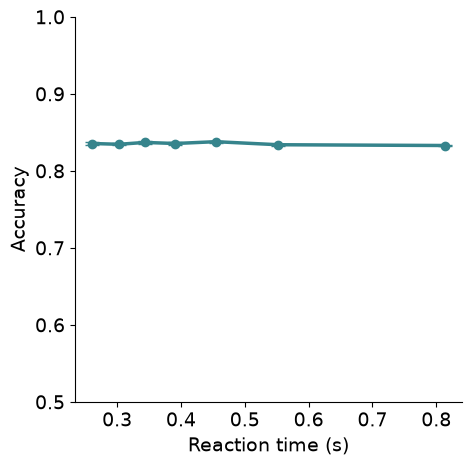

In [96]:
plt.figure(figsize=(5, 5))
plt.errorbar(
    x=summary_stats_vanilla["quantiles_rt_mean_rt"],
    y=summary_stats_vanilla["mean"],
    yerr=summary_stats_vanilla["std"]/np.sqrt(len(np.unique(data_vanilla["subj"]))),  # standard error
    fmt='o-',         # circle marker with line
    linewidth=2.5,
    capsize=5,         # adds little caps on the error bars
    color='#36848C'
)

plt.xlabel("Reaction time (s)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim(0.5, 1.0)
sns.despine()
#plt.savefig("vanilla_ddm_rt_accuracy.png", dpi=300)

#### Repetition matrix

#### Fast/slow: median split based on error trials

In [99]:
median_rt_per_subj = (
    data_vanilla.loc[data_vanilla["accuracy"] == 0]
    .loc[data_vanilla["accuracy"] == 0]
    .groupby("subj", as_index=False)["rt"]
    .median()
    .rename(columns={"rt": "median_rt_incorrect"}))

data_vanilla = data_vanilla.merge(median_rt_per_subj, on="subj", how="left")
data_vanilla["slow_response"] = data_vanilla["rt"] > data_vanilla["median_rt_incorrect"]

data_vanilla["condition"] = np.select([(data_vanilla["resp"] == 1) & (~data_vanilla["slow_response"]),
                                        (data_vanilla["resp"] == 1) & (data_vanilla["slow_response"]),
                                        (data_vanilla["resp"] == -1) & (~data_vanilla["slow_response"]),
                                        (data_vanilla["resp"] == -1) & (data_vanilla["slow_response"]),],
                                        
                                        ["fast_right",
                                        "slow_right",
                                        "fast_left",
                                        "slow_left",],
                                        
                                        default="no_response")

# Create lagged variables
data_vanilla["prev_condition"] = data_vanilla["condition"].shift(1)
data_vanilla["prev_accuracy"] = data_vanilla["accuracy"].shift(1)

In [100]:
data_vanilla

,subj,stimulus,resp,rt,accuracy,quantiles_rt,median_rt_incorrect_x,slow_response,condition,prev_condition,prev_accuracy,median_rt_incorrect_y,median_rt_incorrect
0,1,-1,-1.0,0.505,1,6,0.390,True,slow_left,NaN,NaN,0.390,0.390
1,1,-1,-1.0,0.370,1,4,0.390,False,fast_left,slow_left,1.0,0.390,0.390
2,1,1,1.0,0.480,1,5,0.390,True,slow_right,fast_left,1.0,0.390,0.390
3,1,1,-1.0,0.315,0,2,0.390,False,fast_left,slow_right,1.0,0.390,0.390
4,1,1,1.0,0.450,1,5,0.390,True,slow_right,fast_left,0.0,0.390,0.390
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,50,1,1.0,0.435,1,5,0.385,True,slow_right,slow_right,1.0,0.385,0.385
499996,50,1,1.0,0.335,1,3,0.385,False,fast_right,slow_right,1.0,0.385,0.385
499997,50,1,1.0,0.315,1,2,0.385,False,fast_right,fast_right,1.0,0.385,0.385
499998,50,-1,-1.0,0.390,1,4,0.385,True,slow_left,fast_right,1.0,0.385,0.385


In [102]:
# check for incorrect responses on current and previous trial
data_incorrect_vanilla = data_vanilla[(data_vanilla["accuracy"] == 0) & (data_vanilla["prev_accuracy"] == 0)]

In [103]:
cols = ["subj", "condition", "prev_condition"]

# get all unique levels for each column
levels = [data_incorrect_vanilla[c].unique() for c in cols]

# build full index of all possible combinations
full_index = pd.MultiIndex.from_product(levels, names=cols)

# count occurrences
freq_incorrect_vanilla = (
    data_incorrect_vanilla
    .groupby(cols)
    .size()
    .reindex(full_index, fill_value=0)
    .reset_index(name="count")
)

freq_incorrect_vanilla

,subj,condition,prev_condition,count
0,1,fast_left,slow_left,26
1,1,fast_left,fast_left,16
2,1,fast_left,fast_right,17
3,1,fast_left,slow_right,15
4,1,fast_right,slow_left,16
...,...,...,...,...
795,50,slow_right,slow_right,13
796,50,slow_left,slow_left,16
797,50,slow_left,fast_left,9
798,50,slow_left,fast_right,14


In [104]:
# Conditional proportions (for condition) within each subject
cond_prop_table_subject_vanilla = freq_incorrect_vanilla
cond_prop_table_subject_vanilla["cond_prop"] = cond_prop_table_subject_vanilla.groupby(["subj", "condition"])["count"].transform(lambda x: x / x.sum())
cond_prop_table_subject_vanilla

,subj,condition,prev_condition,count,cond_prop
0,1,fast_left,slow_left,26,0.351351
1,1,fast_left,fast_left,16,0.216216
2,1,fast_left,fast_right,17,0.229730
3,1,fast_left,slow_right,15,0.202703
4,1,fast_right,slow_left,16,0.231884
...,...,...,...,...,...
795,50,slow_right,slow_right,13,0.224138
796,50,slow_left,slow_left,16,0.290909
797,50,slow_left,fast_left,9,0.163636
798,50,slow_left,fast_right,14,0.254545


In [105]:
mean_sd_subjects_vanilla = (
    cond_prop_table_subject_vanilla.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

mean_sd_subjects_vanilla

,condition,prev_condition,mean,std
0,fast_left,fast_left,0.253475,0.054806
1,fast_left,fast_right,0.258173,0.061769
2,fast_left,slow_left,0.235251,0.046526
3,fast_left,slow_right,0.253101,0.049511
4,fast_right,fast_left,0.253493,0.050323
5,fast_right,fast_right,0.259024,0.046181
6,fast_right,slow_left,0.245673,0.049945
7,fast_right,slow_right,0.241810,0.044688
8,slow_left,fast_left,0.262762,0.056126
9,slow_left,fast_right,0.247375,0.047419


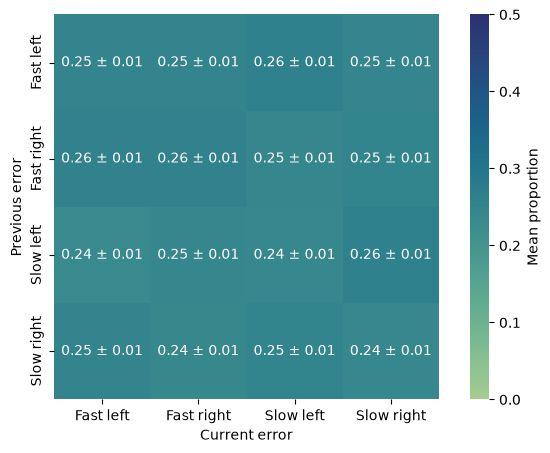

In [106]:
# Put in matrix form
prop_table_mean = mean_sd_subjects_vanilla.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_vanilla.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(data_vanilla['subj'])))).round(2).astype(str)
condition_labels = ['Fast left', 'Fast right', 'Slow left', 'Slow right']

plt.figure(figsize=(8,5))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0,
    vmax = 0.5,
    cbar_kws={'label': 'Mean proportion'},
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True
)


plt.ylabel("Previous error")
plt.xlabel("Current error")
plt.show()

In [107]:
fontsize_heatmap=34

Text(0.5, 124.38563368055553, 'Current error')

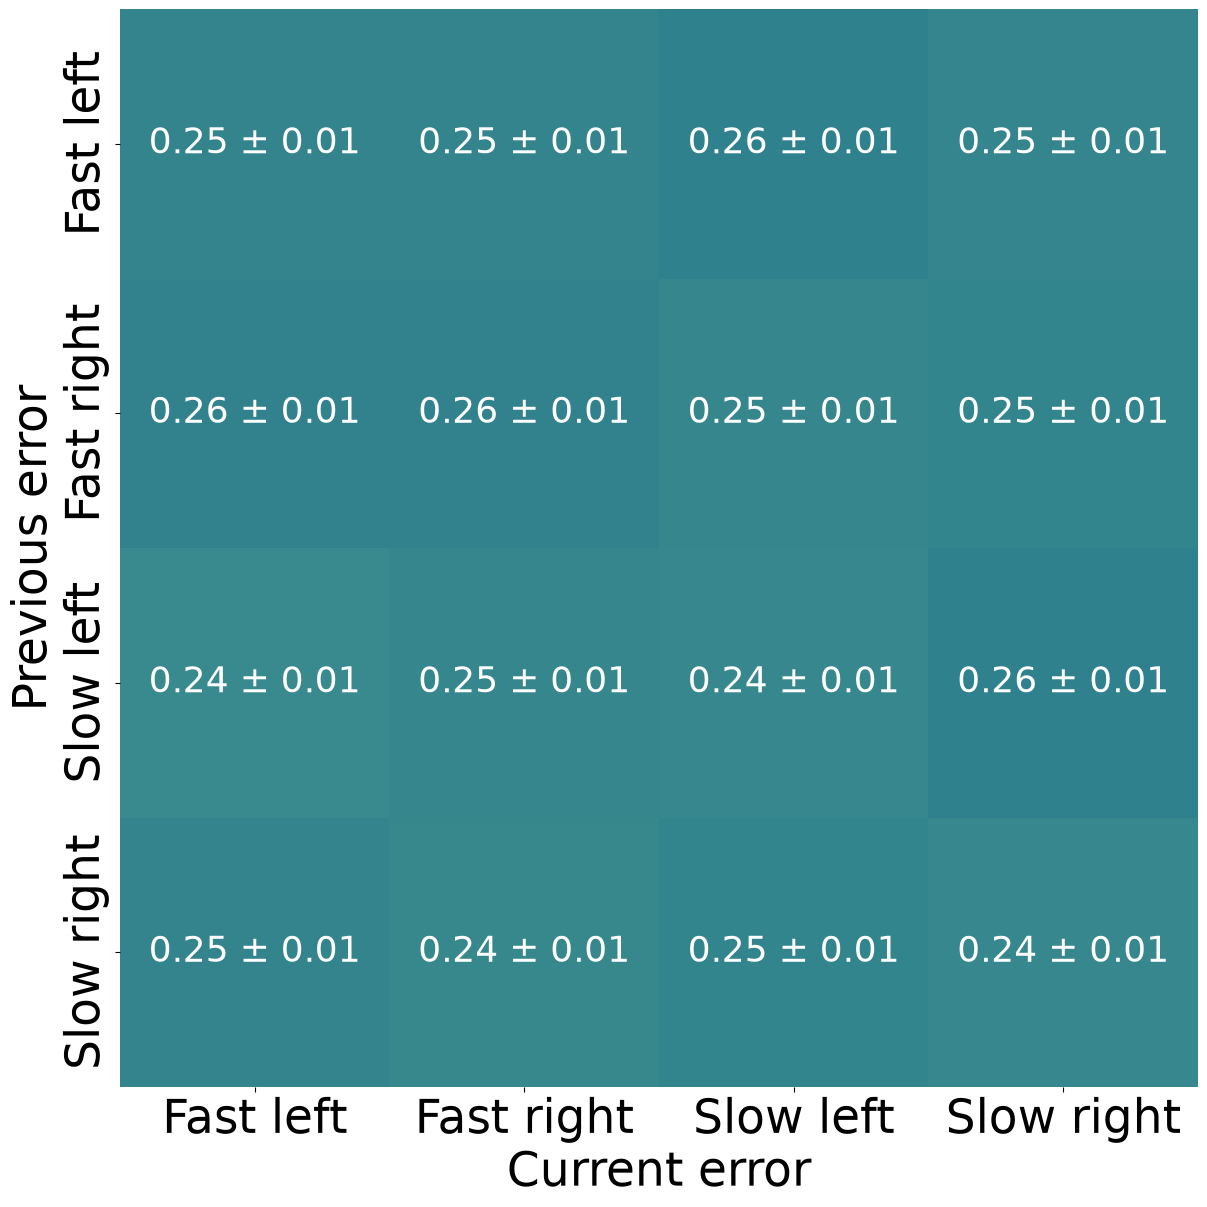

In [108]:
# Put in matrix form
prop_table_mean = mean_sd_subjects_vanilla.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_vanilla.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(data_vanilla['subj'])))).round(2).astype(str)
condition_labels = ['Fast left', 'Fast right', 'Slow left', 'Slow right']

plt.figure(figsize=(14,14))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0,
    vmax = 0.5,
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False
)

ax.tick_params(axis='x', labelsize=fontsize_heatmap)
ax.tick_params(axis='y', labelsize=fontsize_heatmap)

for text in ax.texts:
    text.set_fontsize(26)

plt.ylabel("Previous error", fontsize=fontsize_heatmap)
plt.xlabel("Current error", fontsize=fontsize_heatmap)
#plt.savefig("vanilla_ddm_clustering.png", dpi=300)

### Simulations: across-trial variability DDM

DDM with drift rate $v$, starting point $z$, boundary separation $a$, and non-decision time $T_{er}$.

Across-trial variability parameters are included. On each trial $t$, $v_t$ is drawn from N($v$, $s_v$) and $z_t$ is drawn from U($z$ - $s_z$, $z$ + $s_z$)

In [109]:
# Across-trial variability in drift rate and starting point
sv = 1.25
sz = 0.75

for subject in range(num_subjects):

    stimulus = np.random.permutation(np.repeat(-1, num_trials/2).tolist() + np.repeat(1, num_trials/2).tolist())

    # Draw trial-wise drift rates and starting points
    v_t = np.random.normal(v, sv, num_trials)
    z_t = np.random.uniform(z - sz/2, z + sz/2, num_trials)

    all_resp = np.zeros(num_trials)
    all_rt = np.zeros(num_trials)

    # Loop over trials
    for trial in range(num_trials):

        evidence = a * z_t[trial] # initialize first value (starting point plus bias relative to boundary)
        slope = stimulus[trial] * v_t[trial] * dt
        n_iter = 0
        
        # Loop within trial
        while evidence > 0 and evidence < a and n_iter < max_iter:
            n_iter += 1
            evidence += slope + c * np.random.normal()

        rt = n_iter * dt + ter

        if evidence >= a:
            resp =  1
        elif evidence <= 0:
            resp = -1
        else:
            resp = -99
            
        all_resp[trial] = resp
        all_rt[trial] = rt


    df_subject = pd.DataFrame({
        "subj": subject + 1,
        "stimulus": stimulus,
        "resp": all_resp,
        "rt": all_rt
    })  

    if subject == 0:
        data_variability = df_subject
    else:
        data_variability = pd.concat([data_variability, df_subject], ignore_index=True)

In [110]:
data_variability

,subj,stimulus,resp,rt
0,1,-1,-1.0,0.625
1,1,1,1.0,0.370
2,1,1,1.0,0.500
3,1,-1,-1.0,0.515
4,1,1,-1.0,1.690
...,...,...,...,...
499995,50,-1,-1.0,0.240
499996,50,-1,-1.0,0.230
499997,50,1,-1.0,0.300
499998,50,1,1.0,0.315


In [111]:
# Create accuracy variable
data_variability['accuracy'] = (data_variability['resp'] == data_variability['stimulus']).astype(int)

# Create RT quantiles per subject
data_variability["quantiles_rt"] = (
    data_variability
    .groupby("subj")["rt"]
    .transform(lambda x: pd.qcut(x, q=7, labels=range(1, 8)))
)

# Calculate mean accuracy per RT quantile and subject
mean_accuracy_variability = data_variability.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean", "std"]).reset_index()
mean_accuracy_variability

,quantiles_rt,subj,mean,std
0,1,1,0.686919,0.463891
1,1,2,0.682107,0.465806
2,1,3,0.681312,0.466112
3,1,4,0.707182,0.455195
4,1,5,0.690462,0.462446
...,...,...,...,...
345,7,46,0.706970,0.455314
346,7,47,0.727009,0.445657
347,7,48,0.712386,0.452809
348,7,49,0.703203,0.457009


In [112]:
summary_stats_variability = mean_accuracy_variability.groupby("quantiles_rt", observed=False)["mean"].agg(["mean", "std"]).reset_index()
summary_stats_variability

,quantiles_rt,mean,std
0,1,0.685622,0.011958
1,2,0.735410,0.011780
2,3,0.761479,0.011626
3,4,0.770456,0.011276
4,5,0.770497,0.010350
5,6,0.756958,0.011296
6,7,0.709423,0.009098


#### Conditional accuracy plot

In [113]:
average_rt_variability = data_variability.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean", "std"]).reset_index()

labels_average_rt_variability = average_rt_variability.groupby(["quantiles_rt"], observed=False)["mean"].agg(["mean", "std"]).reset_index()
labels_average_rt_variability

,quantiles_rt,mean,std
0,1,0.227930,0.000929
1,2,0.264116,0.001292
2,3,0.302189,0.001309
3,4,0.348614,0.002061
4,5,0.410192,0.002749
5,6,0.506277,0.003747
6,7,0.777543,0.006977


In [114]:
summary_stats_variability['quantiles_rt_mean_rt'] = labels_average_rt_variability['mean']

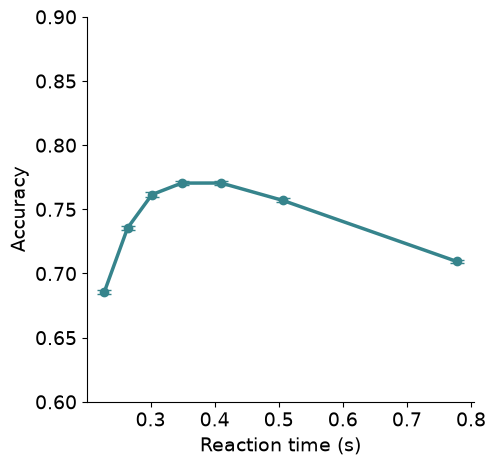

In [115]:
plt.figure(figsize=(5, 5))
plt.errorbar(
    x=summary_stats_variability["quantiles_rt_mean_rt"],
    y=summary_stats_variability["mean"],
    yerr=summary_stats_variability["std"]/np.sqrt(len(np.unique(data_variability["subj"]))),  # standard error
    fmt='o-',         # circle marker with line
    linewidth=2.5,
    capsize=5,         # adds little caps on the error bars
    color='#36848C'
)

plt.xlabel("Reaction time (s)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14) 
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim(0.6, 0.9)
sns.despine()
#plt.savefig("variability_ddm_rt_accuracy.png", dpi=300)

In [116]:
# Compute subject-wise mean RT for correct responses only
median_rt_per_subj = (
    data_variability.loc[data_variability["accuracy"] == 0]
    .groupby("subj", as_index=False)["rt"]
    .median()
    .rename(columns={"rt": "median_rt_incorrect"}))

data_variability = data_variability.merge(median_rt_per_subj, on="subj", how="left")
data_variability["slow_response"] = data_variability["rt"] > data_variability["median_rt_incorrect"]

data_variability["condition"] = np.select([(data_variability["resp"] == 1) & (~data_variability["slow_response"]),
                                           (data_variability["resp"] == 1) & (data_variability["slow_response"]),
                                           (data_variability["resp"] == -1) & (~data_variability["slow_response"]),
                                           (data_variability["resp"] == -1) & (data_variability["slow_response"]),],
                                        
                                        ["fast_right",
                                        "slow_right",
                                        "fast_left",
                                        "slow_left",],
                                        
                                        default="no_response")

# Create lagged variables
data_vanilla["prev_condition"] = data_vanilla["condition"].shift(1)
data_vanilla["prev_accuracy"] = data_vanilla["accuracy"].shift(1)

# Create lagged variables
data_variability["prev_condition"] = data_variability["condition"].shift(1)
data_variability["prev_accuracy"] = data_variability["accuracy"].shift(1)

In [117]:
# Check for incorrect responses on current and previous trial
data_incorrect_variability = data_variability[(data_variability["accuracy"] == 0) & (data_variability["prev_accuracy"] == 0)]

In [118]:
cols = ["subj", "condition", "prev_condition"]

# get all unique levels for each column
levels = [data_incorrect_variability[c].unique() for c in cols]

# build full index of all possible combinations
full_index = pd.MultiIndex.from_product(levels, names=cols)

# count occurrences
freq_incorrect_variability = (
    data_incorrect_variability
    .groupby(cols)
    .size()
    .reindex(full_index, fill_value=0)
    .reset_index(name="count")
)

freq_incorrect_variability

,subj,condition,prev_condition,count
0,1,slow_right,fast_right,32
1,1,slow_right,slow_right,36
2,1,slow_right,slow_left,33
3,1,slow_right,fast_left,44
4,1,slow_left,fast_right,47
...,...,...,...,...
795,50,fast_right,fast_left,39
796,50,fast_left,fast_right,44
797,50,fast_left,slow_right,47
798,50,fast_left,slow_left,37


In [119]:
# Conditional proportions within each subject
cond_prop_table_subject_variability = freq_incorrect_variability
cond_prop_table_subject_variability["cond_prop"] = cond_prop_table_subject_variability.groupby(["subj", "condition"])["count"].transform(lambda x: x / x.sum())
cond_prop_table_subject_variability

,subj,condition,prev_condition,count,cond_prop
0,1,slow_right,fast_right,32,0.220690
1,1,slow_right,slow_right,36,0.248276
2,1,slow_right,slow_left,33,0.227586
3,1,slow_right,fast_left,44,0.303448
4,1,slow_left,fast_right,47,0.270115
...,...,...,...,...,...
795,50,fast_right,fast_left,39,0.234940
796,50,fast_left,fast_right,44,0.275000
797,50,fast_left,slow_right,47,0.293750
798,50,fast_left,slow_left,37,0.231250


In [120]:
mean_sd_subjects_variability = (
    cond_prop_table_subject_variability.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

mean_sd_subjects_variability

,condition,prev_condition,mean,std
0,fast_left,fast_left,0.246292,0.030515
1,fast_left,fast_right,0.250762,0.038045
2,fast_left,slow_left,0.246262,0.037245
3,fast_left,slow_right,0.256684,0.038160
4,fast_right,fast_left,0.250488,0.032717
5,fast_right,fast_right,0.256029,0.033226
6,fast_right,slow_left,0.244651,0.036448
7,fast_right,slow_right,0.248833,0.036247
8,slow_left,fast_left,0.251959,0.034886
9,slow_left,fast_right,0.260224,0.035056


#### Repetition matrix

Text(0.5, 36.38563368055554, 'Current error')

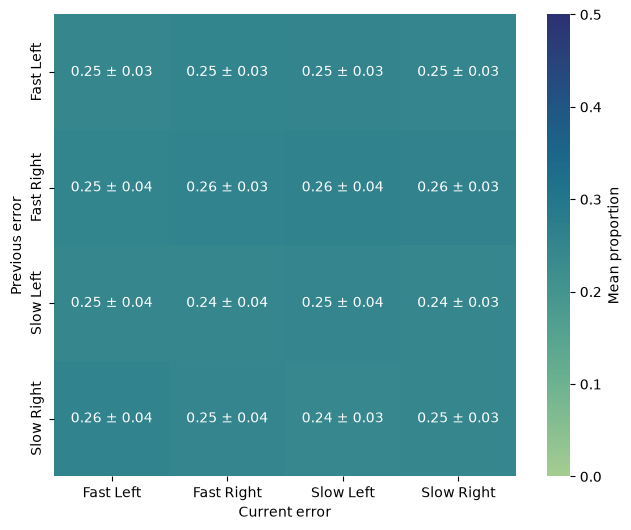

In [121]:
# Put in matrix form
prop_table_mean = mean_sd_subjects_variability.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_variability.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + prop_table_std.round(2).astype(str)
condition_labels = ['Fast Left', 'Fast Right', 'Slow Left', 'Slow Right']

plt.figure(figsize=(8,6))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0,
    vmax = 0.5,
    cbar_kws={'label': 'Mean proportion'},
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True
)

plt.ylabel("Previous error")
plt.xlabel("Current error")
#plt.savefig("across_trial_variability_ddm_clustering.svg", dpi=600)

##### Plot for paper

Text(0.5, 124.38563368055553, 'Current error')

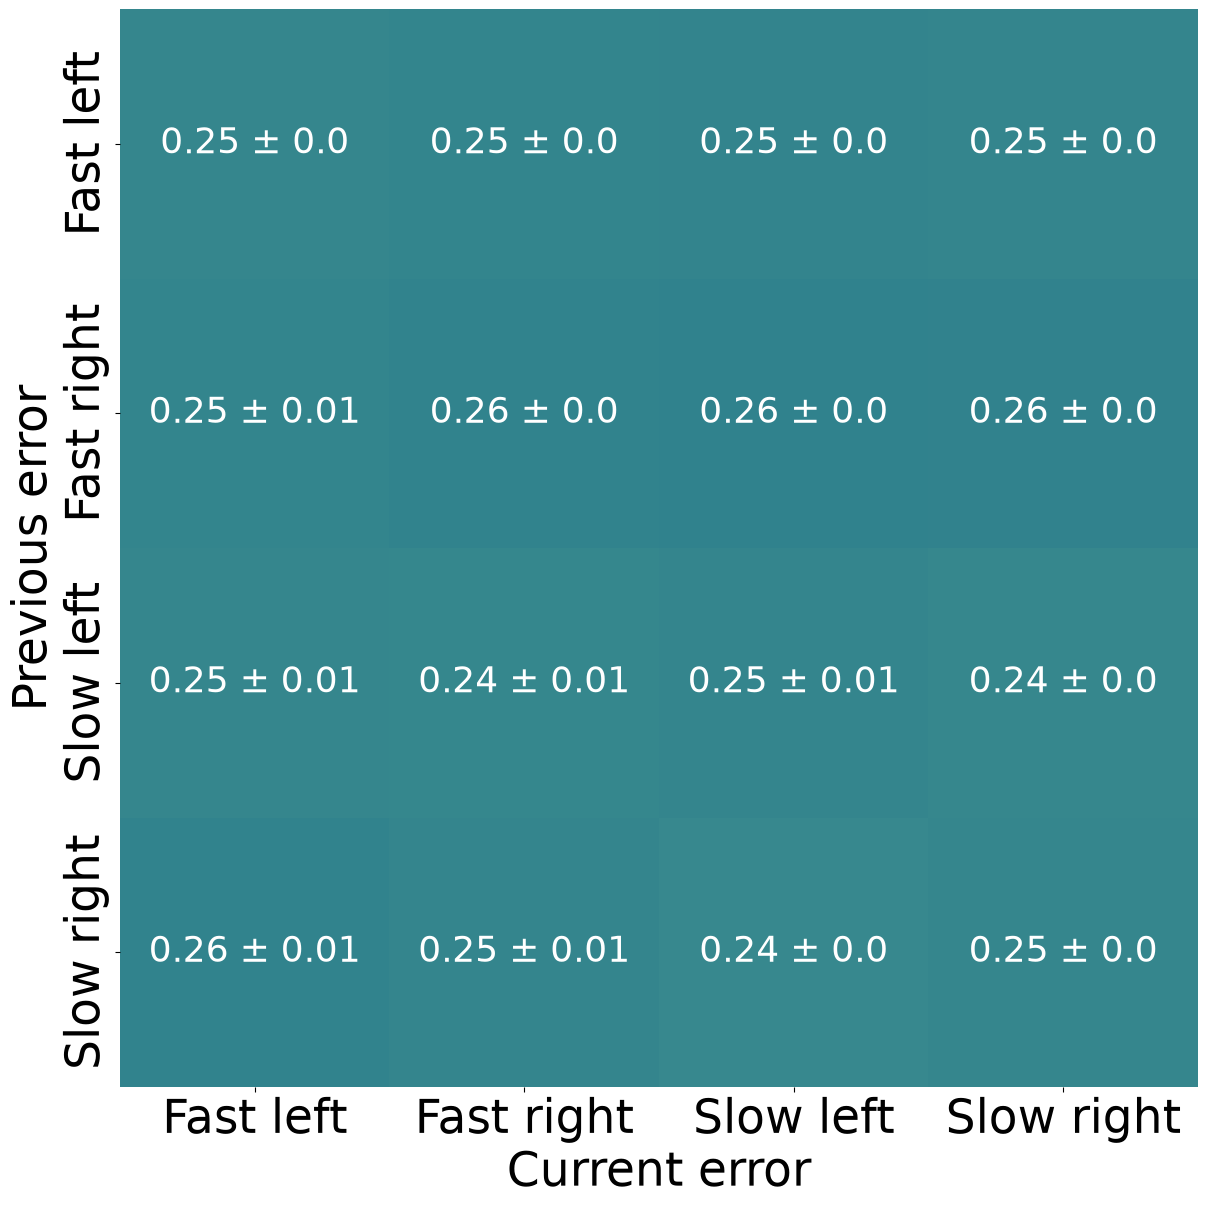

In [122]:
# Put in matrix form
prop_table_mean = mean_sd_subjects_variability.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_variability.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(data_variability['subj'])))).round(2).astype(str)
condition_labels = ['Fast left', 'Fast right', 'Slow left', 'Slow right']

plt.figure(figsize=(14,14))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",  
    vmin = 0,
    vmax = 0.5,
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False
)

ax.tick_params(axis='x', labelsize=fontsize_heatmap)
ax.tick_params(axis='y', labelsize=fontsize_heatmap)

for text in ax.texts:
    text.set_fontsize(26)

plt.ylabel("Previous error", fontsize=fontsize_heatmap)
plt.xlabel("Current error", fontsize=fontsize_heatmap)
#plt.savefig("variability_ddm_clustering.png", dpi=300)

### Simulations: autocorrelated DDM

DDM with drift rate $v$, starting point $z$, boundary separation $a$, and non-decision time $T_{er}$.

Instead of assuming random noise for across-trial variability we now implement autocorrelated fluctuations of $v$ and $z$. From trial-to-trial $v$ follows an AR(1) process: $v_t$ = $\phi_v$ $v_{t-1}$ + $\epsilon_{v,t}$ with $\epsilon_{v,t}$ ~ N(0, $\sigma_{v,t}$). 

Similary, $z$ also fluctuates according to an AR(1) process: $z_t$ = $\phi_z$ $z_{t-1}$ + $\epsilon_{z,t}$ with $\epsilon_{z,t}$ ~ N(0, $\sigma_{z,t}$).

In [123]:
np.random.seed(12345)

z_auto_ddm = 0.0 # z will be sigmoid transformed so 0.0 will correspond to 0.5 (unbiased starting point)


phi_v = 0.99
phi_z = 0.99
phi_a = 0.99

#phi_ter = 0.0

sigma_v = 0.2
sigma_z = 0.1
sigma_a = 0.1

#sigma_ter = 0.0001

# Draw trial-wise drift rates and starting points
v_t = np.zeros((num_subjects, num_trials))
z_t = np.zeros((num_subjects, num_trials))
ter_t = np.zeros((num_subjects, num_trials))
a_t = np.zeros((num_subjects, num_trials))

for subject in range(num_subjects):
    for trial in range(1, num_trials):

        # Drift rate
        v_t[subject, trial] = phi_v * v_t[subject, trial-1] + np.random.normal(0.0, sigma_v)

        # Starting point
        z_t[subject, trial] = phi_z * z_t[subject, trial-1] + np.random.normal(0.0, sigma_z)

        # Boundary separation
        a_t[subject, trial] = np.clip(
                            phi_a * a_t[subject, trial-1] + np.random.normal(0.0, sigma_a),
                            a_min=0.5-a, a_max=1e5 # restrict a_t such that a + a_t is always > 0.5
                        )

        # # Non-decision time
        # ter_t[subject, trial] = np.clip(
        #                     phi_ter * ter_t[subject, trial-1] + np.random.normal(0.0, sigma_ter),
        #                     a_min=0-ter, a_max=1e5
        #                 )

In [124]:
subj_id = 0

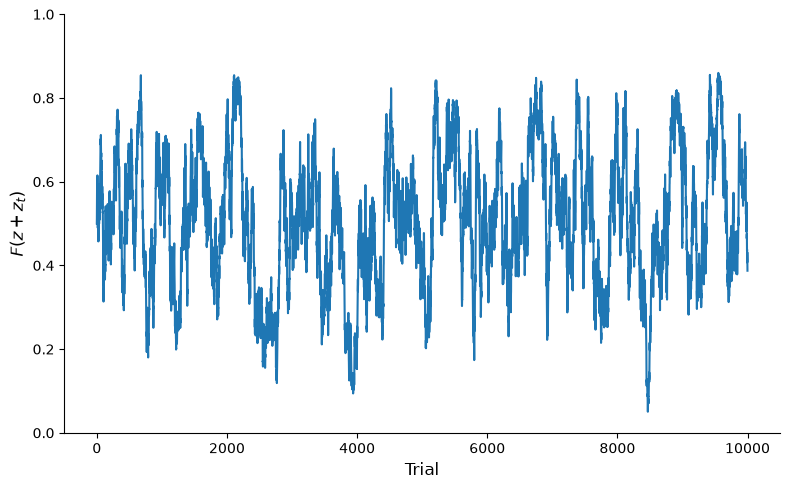

In [130]:
plt.figure(figsize=(8, 5))
plt.plot(1/(1+np.exp(-(z_auto_ddm+z_t[subj_id,:]))))
plt.xlabel("Trial", fontsize=12)
plt.ylabel("$F(z+z_t)$", fontsize=12)
plt.ylim(0,1)
sns.despine()
plt.tight_layout()
plt.show()

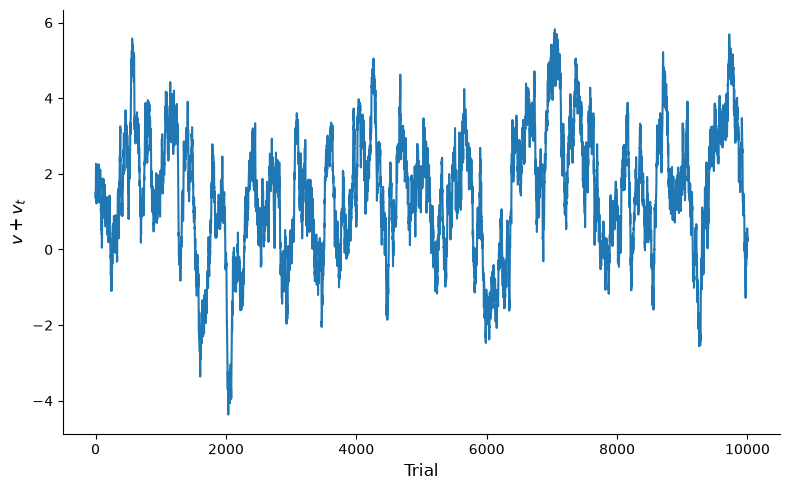

In [129]:
plt.figure(figsize=(8, 5))
plt.plot(v + v_t[subj_id,:])
plt.xlabel("Trial", fontsize=12)
plt.ylabel("$v + v_t$", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

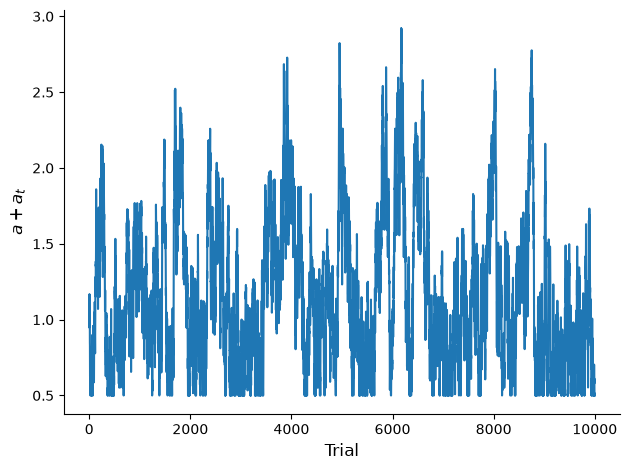

In [131]:
plt.plot(a+a_t[subj_id,:])
plt.xlabel("Trial", fontsize=12)
plt.ylabel("$a + a_t$", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

In [132]:
for subject in range(num_subjects):
    
    stimulus = np.random.permutation(np.repeat(-1, num_trials/2).tolist() + np.repeat(1, num_trials/2).tolist())

    # Sigmoid transform starting point to keep it between 0 and 1
    z_t_sigmoid = 1 / (1 + np.exp(-(z_auto_ddm + z_t[subject, :])))
    
    all_resp = np.zeros(num_trials)
    all_rt = np.zeros(num_trials)

    # Loop over trials
    for trial in range(num_trials):
        
        evidence = (a + a_t[subject, trial]) * z_t_sigmoid[trial] # initialize first value (starting point plus bias relative to boundary)
        
        slope =  stimulus[trial] * (v + v_t[subject, trial]) * dt # drift rate implementation
        
        n_iter = 0
        
        # Loop within trial
        while evidence > 0 and evidence < (a + a_t[subject, trial]) and n_iter < max_iter:
            n_iter += 1
            evidence += slope + c * np.random.normal()

        rt = n_iter * dt + ter

        if evidence >= (a + a_t[subject, trial]):
            resp =  1
        elif evidence <= 0:
            resp = -1
        else:
            resp = -99
            
        all_resp[trial] = resp
        all_rt[trial] = rt

    df_subject = pd.DataFrame({
        "subj": subject + 1,
        "stimulus": stimulus,
        "resp": all_resp,
        "rt": all_rt
    })  

    if subject == 0:
        data_autocorrelated = df_subject
    else:
        data_autocorrelated = pd.concat([data_autocorrelated, df_subject], ignore_index=True)

In [133]:
# Create accuracy variable
data_autocorrelated['accuracy'] = (data_autocorrelated['resp'] == data_autocorrelated['stimulus']).astype(int)

# Create RT quantiles per subject
data_autocorrelated["quantiles_rt"] = (
    data_autocorrelated
    .groupby("subj")["rt"]
    .transform(lambda x: pd.qcut(x, q=7, labels=range(1, 8)))
)

# Calculate mean accuracy per RT quantile and subject
mean_accuracy_autocorrelated = data_autocorrelated.groupby(["quantiles_rt", "subj"], observed=False)["accuracy"].agg(["mean", "std"]).reset_index()
mean_accuracy_autocorrelated

,quantiles_rt,subj,mean,std
0,1,1,0.683634,0.465207
1,1,2,0.706033,0.455723
2,1,3,0.654700,0.475621
3,1,4,0.737166,0.440324
4,1,5,0.688797,0.463146
...,...,...,...,...
345,7,46,0.714888,0.451627
346,7,47,0.729255,0.444501
347,7,48,0.701190,0.457897
348,7,49,0.711238,0.453349


In [134]:
summary_stats_autocorrelated = mean_accuracy_autocorrelated.groupby("quantiles_rt", observed=False)["mean"].agg(["mean", "std"]).reset_index()
summary_stats_autocorrelated

,quantiles_rt,mean,std
0,1,0.712318,0.031285
1,2,0.758128,0.033866
2,3,0.776663,0.034554
3,4,0.788064,0.035759
4,5,0.794114,0.036810
5,6,0.782052,0.039974
6,7,0.736037,0.043815


#### Conditional accuracy plot

In [135]:
average_rt_autocorrelated = data_autocorrelated.groupby(["quantiles_rt", "subj"], observed=False)["rt"].agg(["mean", "std"]).reset_index()

labels_average_rt_autocorrelated = average_rt_autocorrelated.groupby(["quantiles_rt"], observed=False)["mean"].agg(["mean", "std"]).reset_index()
labels_average_rt_autocorrelated

,quantiles_rt,mean,std
0,1,0.236007,0.002740
1,2,0.282358,0.006678
2,3,0.332717,0.011456
3,4,0.397806,0.017949
4,5,0.492247,0.027669
5,6,0.655757,0.046230
6,7,1.281688,0.124559


In [136]:
summary_stats_autocorrelated['quantiles_rt_mean_rt'] = labels_average_rt_autocorrelated['mean']

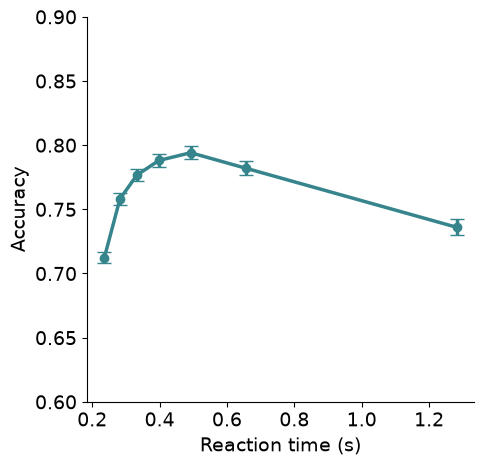

In [137]:
plt.figure(figsize=(5, 5))
plt.errorbar(
    x=summary_stats_autocorrelated["quantiles_rt_mean_rt"],
    y=summary_stats_autocorrelated["mean"],
    yerr=summary_stats_autocorrelated["std"]/np.sqrt(len(np.unique(data_autocorrelated["subj"]))),  # standard error
    fmt='o-',         # circle marker with line
    linewidth=2.5,
    capsize=5,         # adds little caps on the error bars
    color='#36848C'
)

#plt.title("Autocorrelated DDM", fontsize=14, weight="bold")
plt.xlabel("Reaction time (s)", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.ylim(0.6, 0.9)
sns.despine()
#plt.savefig("autocorrelated_ddm_rt_accuracy.png", dpi=300)

#### Median split on only error trials

In [138]:
# Compute subject-wise median RT for incorrect responses only
median_rt_per_subj = (
    data_autocorrelated.loc[data_autocorrelated["accuracy"] == 0]
    .groupby("subj", as_index=False)["rt"]
    .median()
    .rename(columns={"rt": "median_rt_incorrect"})
)

# merge back into the full dataset
data_autocorrelated = data_autocorrelated.merge(median_rt_per_subj, on="subj", how="left")

# Compare each trial RT with the subject median RT
data_autocorrelated["slow_response"] = data_autocorrelated["rt"] > data_autocorrelated["median_rt_incorrect"]

In [139]:
data_autocorrelated["condition"] = np.select([(data_autocorrelated["resp"] == 1) & (~data_autocorrelated["slow_response"]),
                                           (data_autocorrelated["resp"] == 1) & (data_autocorrelated["slow_response"]),
                                           (data_autocorrelated["resp"] == -1) & (~data_autocorrelated["slow_response"]),
                                           (data_autocorrelated["resp"] == -1) & (data_autocorrelated["slow_response"]),],
                                        
                                        ["fast_right",
                                        "slow_right",
                                        "fast_left",
                                        "slow_left",],
                                        
                                        default="no_response")

# Create lagged variables
data_autocorrelated["prev_condition"] = data_autocorrelated["condition"].shift(1)
data_autocorrelated["prev_accuracy"] = data_autocorrelated["accuracy"].shift(1)

In [140]:
# Check for incorrect responses on current and previous trial
data_incorrect_autocorrelated = data_autocorrelated[(data_autocorrelated["accuracy"] == 0) & (data_autocorrelated["prev_accuracy"] == 0)]

In [141]:
cols = ["subj", "condition", "prev_condition"]

# get all unique levels for each column
levels = [data_incorrect_autocorrelated[c].unique() for c in cols]

# build full index of all possible combinations
full_index = pd.MultiIndex.from_product(levels, names=cols)

# count occurrences
freq_incorrect_autocorrelated = (
    data_incorrect_autocorrelated
    .groupby(cols)
    .size()
    .reindex(full_index, fill_value=0)
    .reset_index(name="count")
)

freq_incorrect_autocorrelated

,subj,condition,prev_condition,count
0,1,fast_right,fast_left,79
1,1,fast_right,fast_right,156
2,1,fast_right,slow_left,54
3,1,fast_right,slow_right,47
4,1,fast_left,fast_left,101
...,...,...,...,...
795,50,slow_right,slow_right,72
796,50,slow_left,fast_left,28
797,50,slow_left,fast_right,41
798,50,slow_left,slow_left,65


In [142]:
# Conditional proportions within each subject
cond_prop_table_subject_autocorrelated = freq_incorrect_autocorrelated
cond_prop_table_subject_autocorrelated["cond_prop"] = cond_prop_table_subject_autocorrelated.groupby(["subj", "condition"])["count"].transform(lambda x: x / x.sum()).fillna(0)
cond_prop_table_subject_autocorrelated

,subj,condition,prev_condition,count,cond_prop
0,1,fast_right,fast_left,79,0.235119
1,1,fast_right,fast_right,156,0.464286
2,1,fast_right,slow_left,54,0.160714
3,1,fast_right,slow_right,47,0.139881
4,1,fast_left,fast_left,101,0.358156
...,...,...,...,...,...
795,50,slow_right,slow_right,72,0.306383
796,50,slow_left,fast_left,28,0.136585
797,50,slow_left,fast_right,41,0.200000
798,50,slow_left,slow_left,65,0.317073


In [143]:
# mean_sd_subjects_autocorrelated = (
#     cond_prop_table_subject_autocorrelated.groupby(["condition", "prev_condition"])["count"]
#       .agg(["mean", "std"])
#       .reset_index()
# )

# mean_sd_subjects_autocorrelated

In [144]:
mean_sd_subjects_autocorrelated = (
    cond_prop_table_subject_autocorrelated.groupby(["condition", "prev_condition"])["cond_prop"]
      .agg(["mean", "std"])
      .reset_index()
)

mean_sd_subjects_autocorrelated

,condition,prev_condition,mean,std
0,fast_left,fast_left,0.385154,0.041555
1,fast_left,fast_right,0.237499,0.046859
2,fast_left,slow_left,0.193043,0.029521
3,fast_left,slow_right,0.184304,0.028381
4,fast_right,fast_left,0.228604,0.040406
5,fast_right,fast_right,0.394217,0.041708
6,fast_right,slow_left,0.180412,0.025953
7,fast_right,slow_right,0.196768,0.032273
8,slow_left,fast_left,0.161139,0.035421
9,slow_left,fast_right,0.152721,0.024748


#### Repetition matrix

Text(0.5, 36.38563368055554, 'Current error')

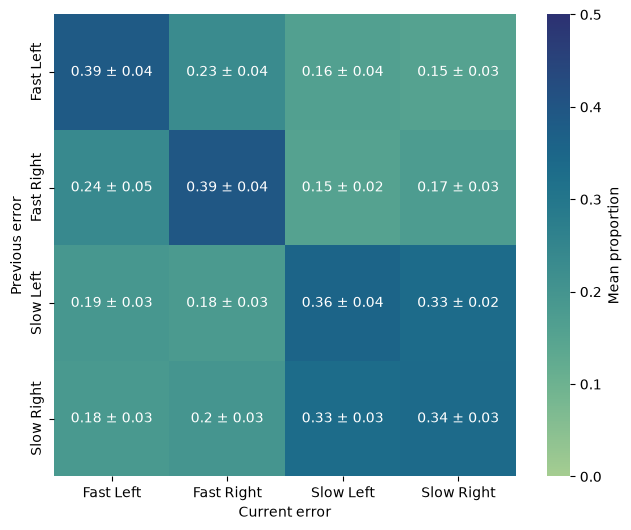

In [145]:
# Put in matrix form
prop_table_mean = mean_sd_subjects_autocorrelated.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_autocorrelated.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + prop_table_std.round(2).astype(str)
condition_labels = ['Fast Left', 'Fast Right', 'Slow Left', 'Slow Right']

plt.figure(figsize=(8,6))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0.0,
    vmax = 0.5,
    cbar_kws={'label': 'Mean proportion'},
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True
)

plt.ylabel("Previous error")
plt.xlabel("Current error")
#plt.savefig("autocorrelated_ddm_repetition_matrix_v.svg", dpi=600)

##### Plot for paper

Text(0.5, 124.38563368055553, 'Current error')

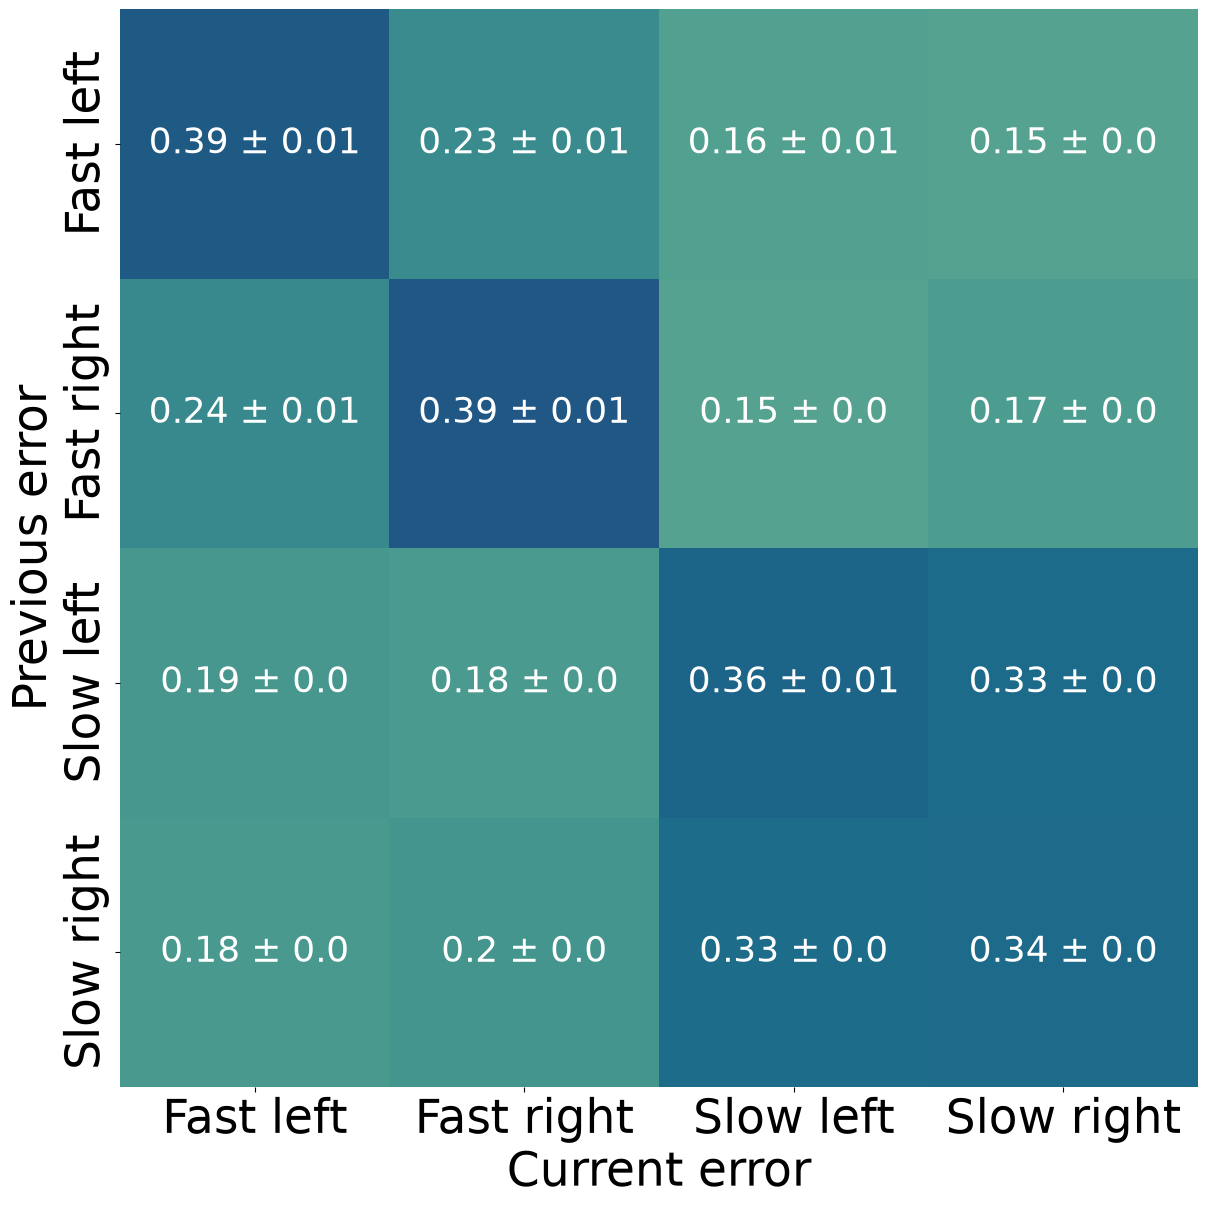

In [146]:
# Put in matrix form
prop_table_mean = mean_sd_subjects_autocorrelated.pivot(index="prev_condition", columns="condition", values="mean")
prop_table_std  = mean_sd_subjects_autocorrelated.pivot(index="prev_condition", columns="condition", values="std")

annot = prop_table_mean.round(2).astype(str) + " ± " + (prop_table_std/np.sqrt(len(np.unique(data_autocorrelated['subj'])))).round(2).astype(str)
condition_labels = ['Fast left', 'Fast right', 'Slow left', 'Slow right']

plt.figure(figsize=(14,14))
ax = sns.heatmap(
    prop_table_mean,
    annot=annot,
    fmt="",
    cmap="crest",
    vmin = 0,
    vmax = 0.5,
    xticklabels=condition_labels,
    yticklabels=condition_labels,
    square=True,
    cbar=False
)

ax.tick_params(axis='x', labelsize=fontsize_heatmap)
ax.tick_params(axis='y', labelsize=fontsize_heatmap)

for text in ax.texts:
    text.set_fontsize(26)

plt.ylabel("Previous error", fontsize=fontsize_heatmap)
plt.xlabel("Current error", fontsize=fontsize_heatmap)
#plt.savefig("autocorrelated_ddm_clustering.png", dpi=300)